In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [35]:
import re
import string

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [36]:
df['review']=df['review'].apply(clean_text)

In [37]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [38]:
X=df['review']

In [39]:
y=df['sentiment']

In [40]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer=Tokenizer(num_words=20000)
tokenizer.fit_on_texts(X)
sequence=tokenizer.texts_to_sequences(X)

In [41]:
max_len=max(len(x) for x in sequence)

In [42]:
max_len = 200

X_padded = pad_sequences(
    sequence,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [43]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
y=encoder.fit_transform(y)

In [44]:
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
positive,0.5
negative,0.5


In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)

In [46]:
vocab_size = 20000

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout

model=Sequential([
    Embedding(vocab_size, 128),
    LSTM(64),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
print(X_train)

[[ 176   46    9 ...    9  147 9499]
 [   9  111   20 ...   26    6 4211]
 [   3 1311  109 ...    0    0    0]
 ...
 [ 834   10   27 ...    0    0    0]
 [  10  355   12 ...    0    0    0]
 [  10    6    3 ...    0    0    0]]


In [50]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping]
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 146ms/step - accuracy: 0.7702 - loss: 0.5127 - val_accuracy: 0.7949 - val_loss: 0.5051
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - accuracy: 0.8266 - loss: 0.4308 - val_accuracy: 0.7881 - val_loss: 0.5226
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.8563 - loss: 0.3832 - val_accuracy: 0.8121 - val_loss: 0.5094


In [51]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7995 - loss: 0.4946
Test Accuracy: 0.7994999885559082


In [52]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test) >= 0.5).astype(int).flatten()

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
              precision    recall  f1-score   support

    negative       0.78      0.82      0.80      4961
    positive       0.82      0.77      0.80      5039

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



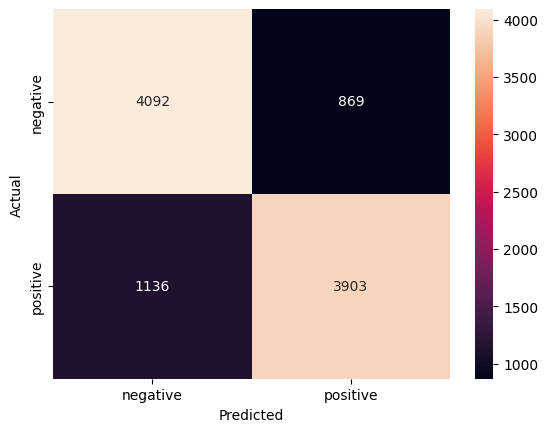

In [53]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [54]:
model.save("imdb_lstm_model.keras")

import pickle

with open("imdb_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("imdb_label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

with open("imdb_max_len.pkl", "wb") as f:
    pickle.dump(max_len, f)

In [55]:
from google.colab import files

files.download("imdb_lstm_model.keras")
files.download("imdb_tokenizer.pkl")
files.download("imdb_label_encoder.pkl")
files.download("imdb_max_len.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>